## Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/online_retail_clean.csv")
rfm = pd.read_csv("../data/processed/customer_rfm.csv")

df["invoice_date"] = pd.to_datetime(df["invoice_date"])

df.head()

,invoice_no,stockcode,description,quantity,invoice_date,unit_price,customer_id,country,source_sheet,is_cancellation,sales_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010,False,30.0


## segment 合并回交易明细

In [3]:
df = df.merge(
    rfm[["customer_id", "segment"]],
    on="customer_id",
    how="left"
)

df.head()

,invoice_no,stockcode,description,quantity,invoice_date,unit_price,customer_id,country,source_sheet,is_cancellation,sales_amount,segment
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010,False,83.4,Loyal Customers
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0,Loyal Customers
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0,Loyal Customers
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010,False,100.8,Loyal Customers
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010,False,30.0,Loyal Customers


In [4]:
df["segment"].value_counts(dropna=False)

segment
Champions              499143
Loyal Customers         98194
At Risk                 69450
Others                  58701
Potential Loyalists     50885
Hibernating             29176
Name: count, dtype: int64

## popularity-based recommendation

### 全局最热商品

按销量排名

In [5]:
global_popularity_qty = (
    df.groupby(["stockcode", "description"], as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("sales_amount", "sum"),
        total_orders=("invoice_no", "nunique"),
        unique_customers=("customer_id", "nunique")
    )
    .sort_values(["total_quantity", "total_revenue"], ascending=[False, False])
)

global_popularity_qty.head(10)

,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
4031,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,109169,24905.87,920,482
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93640,252072.46,4888,1490
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,79913,127074.17,2652,1010
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,138
4725,85099B,JUMBO BAG RED RETROSPOT,75759,136980.08,2612,860
115,17003,BROCADE RING PURSE,71129,14827.71,387,215
1357,21977,PACK OF 60 PINK PAISLEY CAKE CASES,55270,26733.45,1578,767
4595,84991,60 TEATIME FAIRY CAKE CASES,53495,26121.57,1765,822
659,21212,PACK OF 72 RETROSPOT CAKE CASES,46107,22214.26,1348,772


Or by revenue

In [6]:
global_popularity_revenue = (
    df.groupby(["stockcode", "description"], as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("sales_amount", "sum"),
        total_orders=("invoice_no", "nunique"),
        unique_customers=("customer_id", "nunique")
    )
    .sort_values(["total_revenue", "total_quantity"], ascending=[False, False])
)

global_popularity_revenue.head(10)

,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
1862,22423,REGENCY CAKESTAND 3 TIER,24899,286486.30,3317,1314
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93640,252072.46,4888,1490
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1
5309,M,Manual,9803,152340.57,620,438
4725,85099B,JUMBO BAG RED RETROSPOT,75759,136980.08,2612,860
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,79913,127074.17,2652,1010
5311,POST,POSTAGE,5333,126563.04,1803,405
3627,47566,PARTY BUNTING,23607,103880.23,2077,894
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,138
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,29477,79594.33,1691,896


Figure

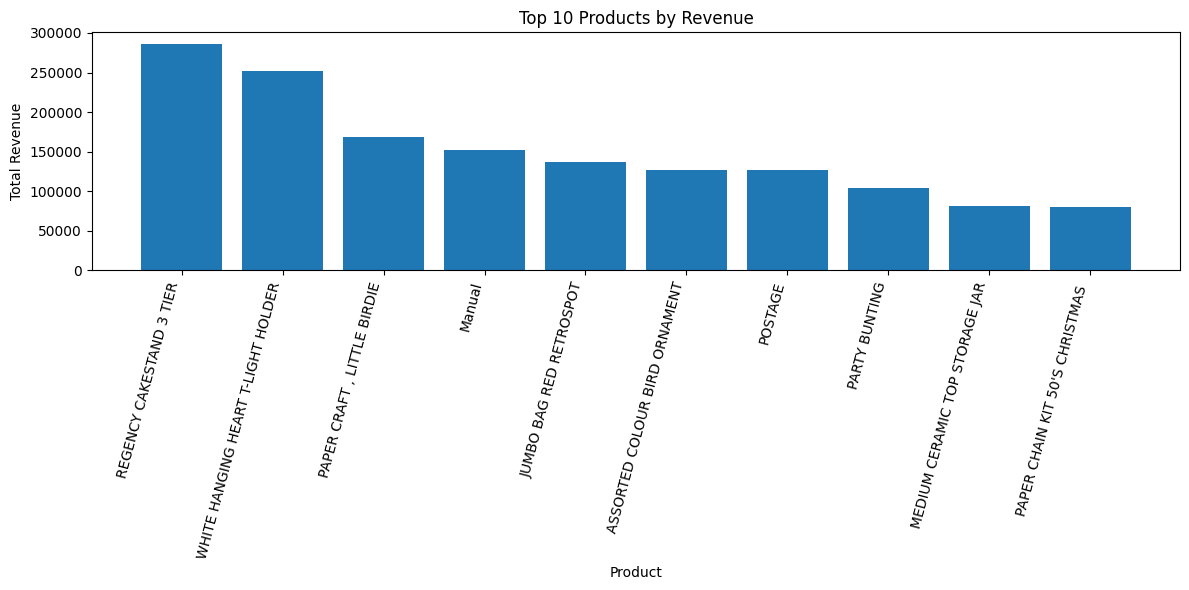

In [7]:
top10_global = global_popularity_revenue.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_global["description"], top10_global["total_revenue"])
plt.xticks(rotation=75, ha="right")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

"推荐函数”：全局 top-N

In [8]:
def recommend_top_n_global(popularity_df, n=5):
    return popularity_df[["stockcode", "description", "total_quantity", "total_revenue"]].head(n)

test

In [9]:
recommend_top_n_global(global_popularity_revenue, n=5)

,stockcode,description,total_quantity,total_revenue
1862,22423,REGENCY CAKESTAND 3 TIER,24899,286486.30
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93640,252072.46
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
5309,M,Manual,9803,152340.57
4725,85099B,JUMBO BAG RED RETROSPOT,75759,136980.08


## segment-based popularity recommendation

各 segment 的热门商品

In [10]:
segment_product_popularity = (
    df.groupby(["segment", "stockcode", "description"], as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("sales_amount", "sum"),
        total_orders=("invoice_no", "nunique"),
        unique_customers=("customer_id", "nunique")
    )
)

In [11]:
segment_product_popularity.head()

,segment,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
0,At Risk,10002,INFLATABLE POLITICAL GLOBE,260,221.00,29,19
1,At Risk,10120,DOGGY RUBBER,64,13.44,3,3
2,At Risk,10123C,HEARTS WRAPPING TAPE,36,23.40,11,10
3,At Risk,10123G,ARMY CAMO WRAPPING TAPE,6,3.90,2,2
4,At Risk,10124A,SPOTS ON RED BOOKCOVER TAPE,2,0.84,2,2


给某个 segment 推荐 top-N 商品

In [12]:
def recommend_top_n_by_segment(segment_name, popularity_df, n=5, sort_by="total_revenue"):
    segment_df = popularity_df[popularity_df["segment"] == segment_name].copy()
    segment_df = segment_df.sort_values(sort_by, ascending=False)
    return segment_df[["segment", "stockcode", "description", "total_quantity", "total_revenue"]].head(n)

In [13]:
recommend_top_n_by_segment("Champions", segment_product_popularity, n=5)

,segment,stockcode,description,total_quantity,total_revenue
5884,Champions,22423,REGENCY CAKESTAND 3 TIER,19565,223157.70
8704,Champions,85123A,WHITE HANGING HEART T-LIGHT HOLDER,63814,171458.52
8678,Champions,85099B,JUMBO BAG RED RETROSPOT,59381,107068.67
8412,Champions,84879,ASSORTED COLOUR BIRD ORNAMENT,62448,98302.56
9230,Champions,POST,POSTAGE,3709,85017.80


In [14]:
recommend_top_n_by_segment("Loyal Customers", segment_product_popularity, n=5)

,segment,stockcode,description,total_quantity,total_revenue
16941,Loyal Customers,85123A,WHITE HANGING HEART T-LIGHT HOLDER,9274,25442.24
14526,Loyal Customers,22423,REGENCY CAKESTAND 3 TIER,2046,24034.60
15994,Loyal Customers,47566,PARTY BUNTING,3851,17022.25
16916,Loyal Customers,85099B,JUMBO BAG RED RETROSPOT,8792,15918.20
17336,Loyal Customers,M,Manual,699,12331.65


In [15]:
recommend_top_n_by_segment("At Risk", segment_product_popularity, n=5)

,segment,stockcode,description,total_quantity,total_revenue
2440,At Risk,23166,MEDIUM CERAMIC TOP STORAGE JAR,74239,77213.60
3667,At Risk,85123A,WHITE HANGING HEART T-LIGHT HOLDER,13675,35949.35
4048,At Risk,M,Manual,308,22283.69
1718,At Risk,22423,REGENCY CAKESTAND 3 TIER,1405,16632.15
483,At Risk,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,6784,14456.10


对比不同客群的商品偏好

In [16]:
segment_top10 = (
    segment_product_popularity
    .sort_values(["segment", "total_revenue"], ascending=[True, False])
    .groupby("segment")
    .head(10)
)

segment_top10.head(20)

,segment,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
2440,At Risk,23166,MEDIUM CERAMIC TOP STORAGE JAR,74239,77213.60,3,3
3667,At Risk,85123A,WHITE HANGING HEART T-LIGHT HOLDER,13675,35949.35,669,224
4048,At Risk,M,Manual,308,22283.69,51,39
1718,At Risk,22423,REGENCY CAKESTAND 3 TIER,1405,16632.15,277,151
483,At Risk,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,6784,14456.10,53,44
1198,At Risk,21915,RED HARMONICA IN BOX,10590,11426.42,72,44
2786,At Risk,48185,DOORMAT FAIRY CAKE,1473,9767.03,45,27
543,At Risk,21175,GIN + TONIC DIET METAL SIGN,5058,9289.65,125,72
1594,At Risk,22328,ROUND SNACK BOXES SET OF 4 FRUITS,3563,9224.45,65,29
3062,At Risk,84078A,SET/4 WHITE RETRO STORAGE CUBES,237,8353.15,23,18


In [17]:
segment_top10.to_csv("../outputs/tables/segment_top10_products.csv", index=False)

## basket / co-occurrence recommendation

如果商品 A 和商品 B 经常在同一订单中一起出现，那么买了 A 的用户可以被推荐 B。

先构造订单-商品表    
我们先保留每个订单里的唯一商品，避免同一订单里重复商品影响共现。

In [18]:
basket_df = df[["invoice_no", "stockcode", "description"]].drop_duplicates()
basket_df.head()

,invoice_no,stockcode,description
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
1,489434,79323P,PINK CHERRY LIGHTS
2,489434,79323W,WHITE CHERRY LIGHTS
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE"
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX


In [19]:
basket_size = (
    basket_df.groupby("invoice_no")["stockcode"]
    .nunique()
    .reset_index(name="unique_products")
)

basket_size.describe()

,invoice_no,unique_products
count,36969.000000,36969.000000
mean,536560.892991,20.797560
std,26579.031367,22.399873
min,489434.000000,1.000000
25%,513878.000000,6.000000
50%,536425.000000,15.000000
75%,559879.000000,27.000000
max,581587.000000,541.000000


构造商品共现对

我们要在同一个订单里，两两配对商品

In [20]:
basket_pairs = basket_df.merge(
    basket_df,
    on="invoice_no"
)

Clean

In [21]:
basket_pairs = basket_pairs[basket_pairs["stockcode_x"] != basket_pairs["stockcode_y"]]
basket_pairs.head()

,invoice_no,stockcode_x,description_x,stockcode_y,description_y
1,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,79323P,PINK CHERRY LIGHTS
2,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,79323W,WHITE CHERRY LIGHTS
3,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,22041,"RECORD FRAME 7"" SINGLE SIZE"
4,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,21232,STRAWBERRY CERAMIC TRINKET BOX
5,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,22064,PINK DOUGHNUT TRINKET POT


In [22]:
basket_pairs = basket_pairs[
    basket_pairs["stockcode_x"] < basket_pairs["stockcode_y"]
].copy()

basket_pairs.head()

,invoice_no,stockcode_x,description_x,stockcode_y,description_y
8,489434,79323P,PINK CHERRY LIGHTS,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
10,489434,79323P,PINK CHERRY LIGHTS,79323W,WHITE CHERRY LIGHTS
16,489434,79323W,WHITE CHERRY LIGHTS,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
24,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
25,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",79323P,PINK CHERRY LIGHTS


统计共现次数

In [23]:
cooccurrence = (
    basket_pairs.groupby(
        ["stockcode_x", "description_x", "stockcode_y", "description_y"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "cooccurrence_count"})
    .sort_values("cooccurrence_count", ascending=False)
)

cooccurrence.head(20)

,stockcode_x,description_x,stockcode_y,description_y,cooccurrence_count
1612213,21733,RED HANGING HEART T-LIGHT HOLDER,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1153
3637991,82482,WOODEN PICTURE FRAME WHITE FINISH,82494L,WOODEN FRAME ANTIQUE WHITE,993
2664488,22469,HEART OF WICKER SMALL,22470,HEART OF WICKER LARGE,869
952409,21231,SWEETHEART CERAMIC TRINKET BOX,21232,STRAWBERRY CERAMIC TRINKET BOX,817
1637987,21754,HOME BUILDING BLOCK WORD,21755,LOVE BUILDING BLOCK WORD,786
342833,20727,LUNCH BAG BLACK SKULL.,22382,LUNCH BAG SPACEBOY DESIGN,774
2967580,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,743
341461,20727,LUNCH BAG BLACK SKULL.,20728,LUNCH BAG CARS BLUE,741
1930272,21977,PACK OF 60 PINK PAISLEY CAKE CASES,84991,60 TEATIME FAIRY CAKE CASES,736
1886143,21931,JUMBO STORAGE BAG SUKI,85099B,JUMBO BAG RED RETROSPOT,733


## 给定商品推荐相似同购商品

我们先基于 co-occurrence count 做最简单推荐。

In [25]:
def recommend_by_product(stockcode, cooccurrence_df, n=5):
    left_matches = cooccurrence_df[cooccurrence_df["stockcode_x"] == stockcode][
        ["stockcode_y", "description_y", "cooccurrence_count"]
    ].rename(columns={
        "stockcode_y": "recommended_stockcode",
        "description_y": "recommended_description"
    })

    right_matches = cooccurrence_df[cooccurrence_df["stockcode_y"] == stockcode][
        ["stockcode_x", "description_x", "cooccurrence_count"]
    ].rename(columns={
        "stockcode_x": "recommended_stockcode",
        "description_x": "recommended_description"
    })

    recommendations = pd.concat([left_matches, right_matches], ignore_index=True)
    recommendations = (
        recommendations.groupby(
            ["recommended_stockcode", "recommended_description"],
            as_index=False
        )["cooccurrence_count"]
        .sum()
        .sort_values("cooccurrence_count", ascending=False)
    )

    return recommendations.head(n)

Test

In [26]:
global_popularity_revenue.head(10)

,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
1862,22423,REGENCY CAKESTAND 3 TIER,24899,286486.30,3317,1314
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,93640,252072.46,4888,1490
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1
5309,M,Manual,9803,152340.57,620,438
4725,85099B,JUMBO BAG RED RETROSPOT,75759,136980.08,2612,860
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,79913,127074.17,2652,1010
5311,POST,POSTAGE,5333,126563.04,1803,405
3627,47566,PARTY BUNTING,23607,103880.23,2077,894
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,138
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,29477,79594.33,1691,896


挑一个stockcode来测试

In [27]:
test_stockcode = global_popularity_revenue.iloc[0]["stockcode"]
test_stockcode

'22423'

In [28]:
recommend_by_product(test_stockcode, cooccurrence, n=10)

,recommended_stockcode,recommended_description,cooccurrence_count
1906,22699,ROSES REGENCY TEACUP AND SAUCER,580
1902,22697,GREEN REGENCY TEACUP AND SAUCER,518
3864,85123A,WHITE HANGING HEART T-LIGHT HOLDER,504
1904,22698,PINK REGENCY TEACUP AND SAUCER,426
3628,84879,ASSORTED COLOUR BIRD ORNAMENT,405
1037,21843,RED RETROSPOT CAKE STAND,366
3052,47566,PARTY BUNTING,324
1134,21977,PACK OF 60 PINK PAISLEY CAKE CASES,296
3842,85099B,JUMBO BAG RED RETROSPOT,295
3725,84991,60 TEATIME FAIRY CAKE CASES,274


加一个 helper，顺便显示商品名字

In [29]:
product_lookup = (
    df[["stockcode", "description"]]
    .drop_duplicates()
    .dropna()
)

product_lookup.head()

,stockcode,description
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
1,79323P,PINK CHERRY LIGHTS
2,79323W,WHITE CHERRY LIGHTS
3,22041,"RECORD FRAME 7"" SINGLE SIZE"
4,21232,STRAWBERRY CERAMIC TRINKET BOX


In [30]:
def get_product_name(stockcode, lookup_df):
    match = lookup_df[lookup_df["stockcode"] == stockcode]
    if not match.empty:
        return match.iloc[0]["description"]
    return "Unknown Product"

test

In [31]:
get_product_name(test_stockcode, product_lookup)

'REGENCY CAKESTAND 3 TIER'

打印一句更完整的话

In [32]:
print("Target product:", test_stockcode, "-", get_product_name(test_stockcode, product_lookup))
recommend_by_product(test_stockcode, cooccurrence, n=10)

Target product: 22423 - REGENCY CAKESTAND 3 TIER


,recommended_stockcode,recommended_description,cooccurrence_count
1906,22699,ROSES REGENCY TEACUP AND SAUCER,580
1902,22697,GREEN REGENCY TEACUP AND SAUCER,518
3864,85123A,WHITE HANGING HEART T-LIGHT HOLDER,504
1904,22698,PINK REGENCY TEACUP AND SAUCER,426
3628,84879,ASSORTED COLOUR BIRD ORNAMENT,405
1037,21843,RED RETROSPOT CAKE STAND,366
3052,47566,PARTY BUNTING,324
1134,21977,PACK OF 60 PINK PAISLEY CAKE CASES,296
3842,85099B,JUMBO BAG RED RETROSPOT,295
3725,84991,60 TEATIME FAIRY CAKE CASES,274


## 给 baseline recommendation 做一个简单评价

看共现对是不是覆盖了很多商品

In [33]:
recommended_products = pd.concat([
    cooccurrence[["stockcode_x"]].rename(columns={"stockcode_x": "stockcode"}),
    cooccurrence[["stockcode_y"]].rename(columns={"stockcode_y": "stockcode"})
]).drop_duplicates()

recommended_products["stockcode"].nunique()

4621

和总商品数对比一下

In [34]:
total_products = df["stockcode"].nunique()
covered_products = recommended_products["stockcode"].nunique()

coverage = covered_products / total_products
coverage

0.9978406391708055

The co-occurrence baseline covers 99.78% of unique products in the cleaned transaction dataset.

## 导出推荐结果

### 全局top商品

In [35]:
global_popularity_revenue.to_csv("../outputs/tables/global_popularity_revenue.csv", index=False)

### segment热门商品

In [36]:
segment_product_popularity.to_csv("../outputs/tables/segment_product_popularity.csv", index=False)

### 共现推荐结果

In [37]:
cooccurrence.to_csv("../outputs/tables/product_cooccurrence.csv", index=False)

## Baseline recommendation insights

1. Global popularity provides a simple and strong baseline for recommendation, especially for new or low-information users.
2. Segment-specific popularity shows that different customer groups may respond to different product mixes, which supports more targeted recommendation strategies.
3. Product co-occurrence reveals meaningful basket relationships that can be used for cross-sell and add-on recommendations.
4. A basket-based baseline is especially relevant for transaction data because it captures observed purchase behavior without requiring explicit ratings.
5 .These baselines provide a practical starting point for later experimentation against more personalized recommendation strategies.

## Business implications

* Use global popularity as a fallback strategy for cold-start recommendation.
* Use segment-based popularity to tailor homepage, campaign, or email recommendations by customer value tier.
* Use co-occurrence recommendations to improve basket expansion and cross-sell performance.
* Compare popularity-based and co-occurrence-based recommendation in simulated A/B tests to estimate potential business uplift.